# Decadal dynamics of global mangrove disturbance rates (1984-2023)

Disturbance includes degradation and loss.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os
import palettable
from tqdm import tqdm
import geopandas as gpd
import cartopy.crs as ccrs
import ZhenPlot
from geemap import cartoee as cee
import geemap

plt.rcParams['font.sans-serif'] = ['Arial']
%config InlineBackend.figure_format = 'retina'

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


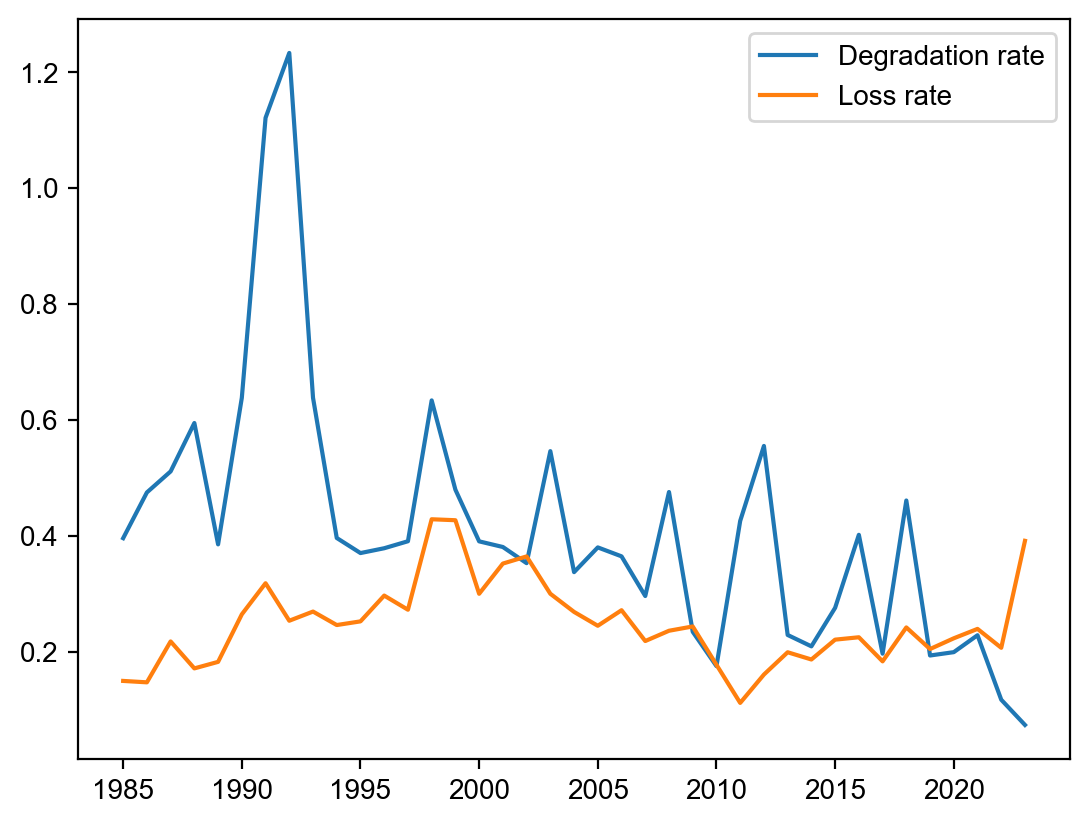

In [2]:
os.chdir(r'D:\OneDriveFolder\OneDrive\Manuscript\GlobalMangroveDynamics\code')
df_degradation = pd.read_csv('Code_Data/ByContinent_AnnualNewDegradation.csv')
df_degradation.set_index(df_degradation.columns[0],inplace=True)
continents = df_degradation.index.sort_values(ascending=True)

continent = continents[0]
total_area =  pd.read_csv(f'Code_Data/EstimatedAnnualChange/Degradation{continent}.csv')['TotalArea']
degradation_area = pd.read_csv(f'Code_Data/EstimatedAnnualChange/Degradation{continent}.csv')['CorrectedDegradationArea']
deforestation_area = pd.read_csv(f'Code_Data/EstimatedAnnualChange/Deforestation{continent}.csv')['CorrectedDeforestationArea']
for i,continent in enumerate(continents[1:]):
    df_degradation = pd.read_csv(f'Code_Data/EstimatedAnnualChange/Degradation{continent}.csv')
    total_area = total_area+df_degradation['TotalArea']
    degradation_area = degradation_area+df_degradation['CorrectedDegradationArea']

    df_deforestation = pd.read_csv(f'Code_Data/EstimatedAnnualChange/Deforestation{continent}.csv')
    deforestation_area = deforestation_area+df_deforestation['CorrectedDeforestationArea']
    
df_globe = pd.DataFrame({'TotalArea':total_area,
                         'CorrectedDegradationArea':degradation_area,
                         'CorrectedDeforestationArea':deforestation_area
                        })
df_globe.dropna(inplace=True)
df_globe['DegradationRate'] = 100*df_globe['CorrectedDegradationArea']/df_globe['TotalArea']
df_globe['DeforestationRate'] = 100*df_globe['CorrectedDeforestationArea']/df_globe['TotalArea']
plt.plot(range(1985,2024),df_globe['DegradationRate'],label='Degradation rate')
plt.plot(range(1985,2024),df_globe['DeforestationRate'],label='Loss rate')
plt.legend()

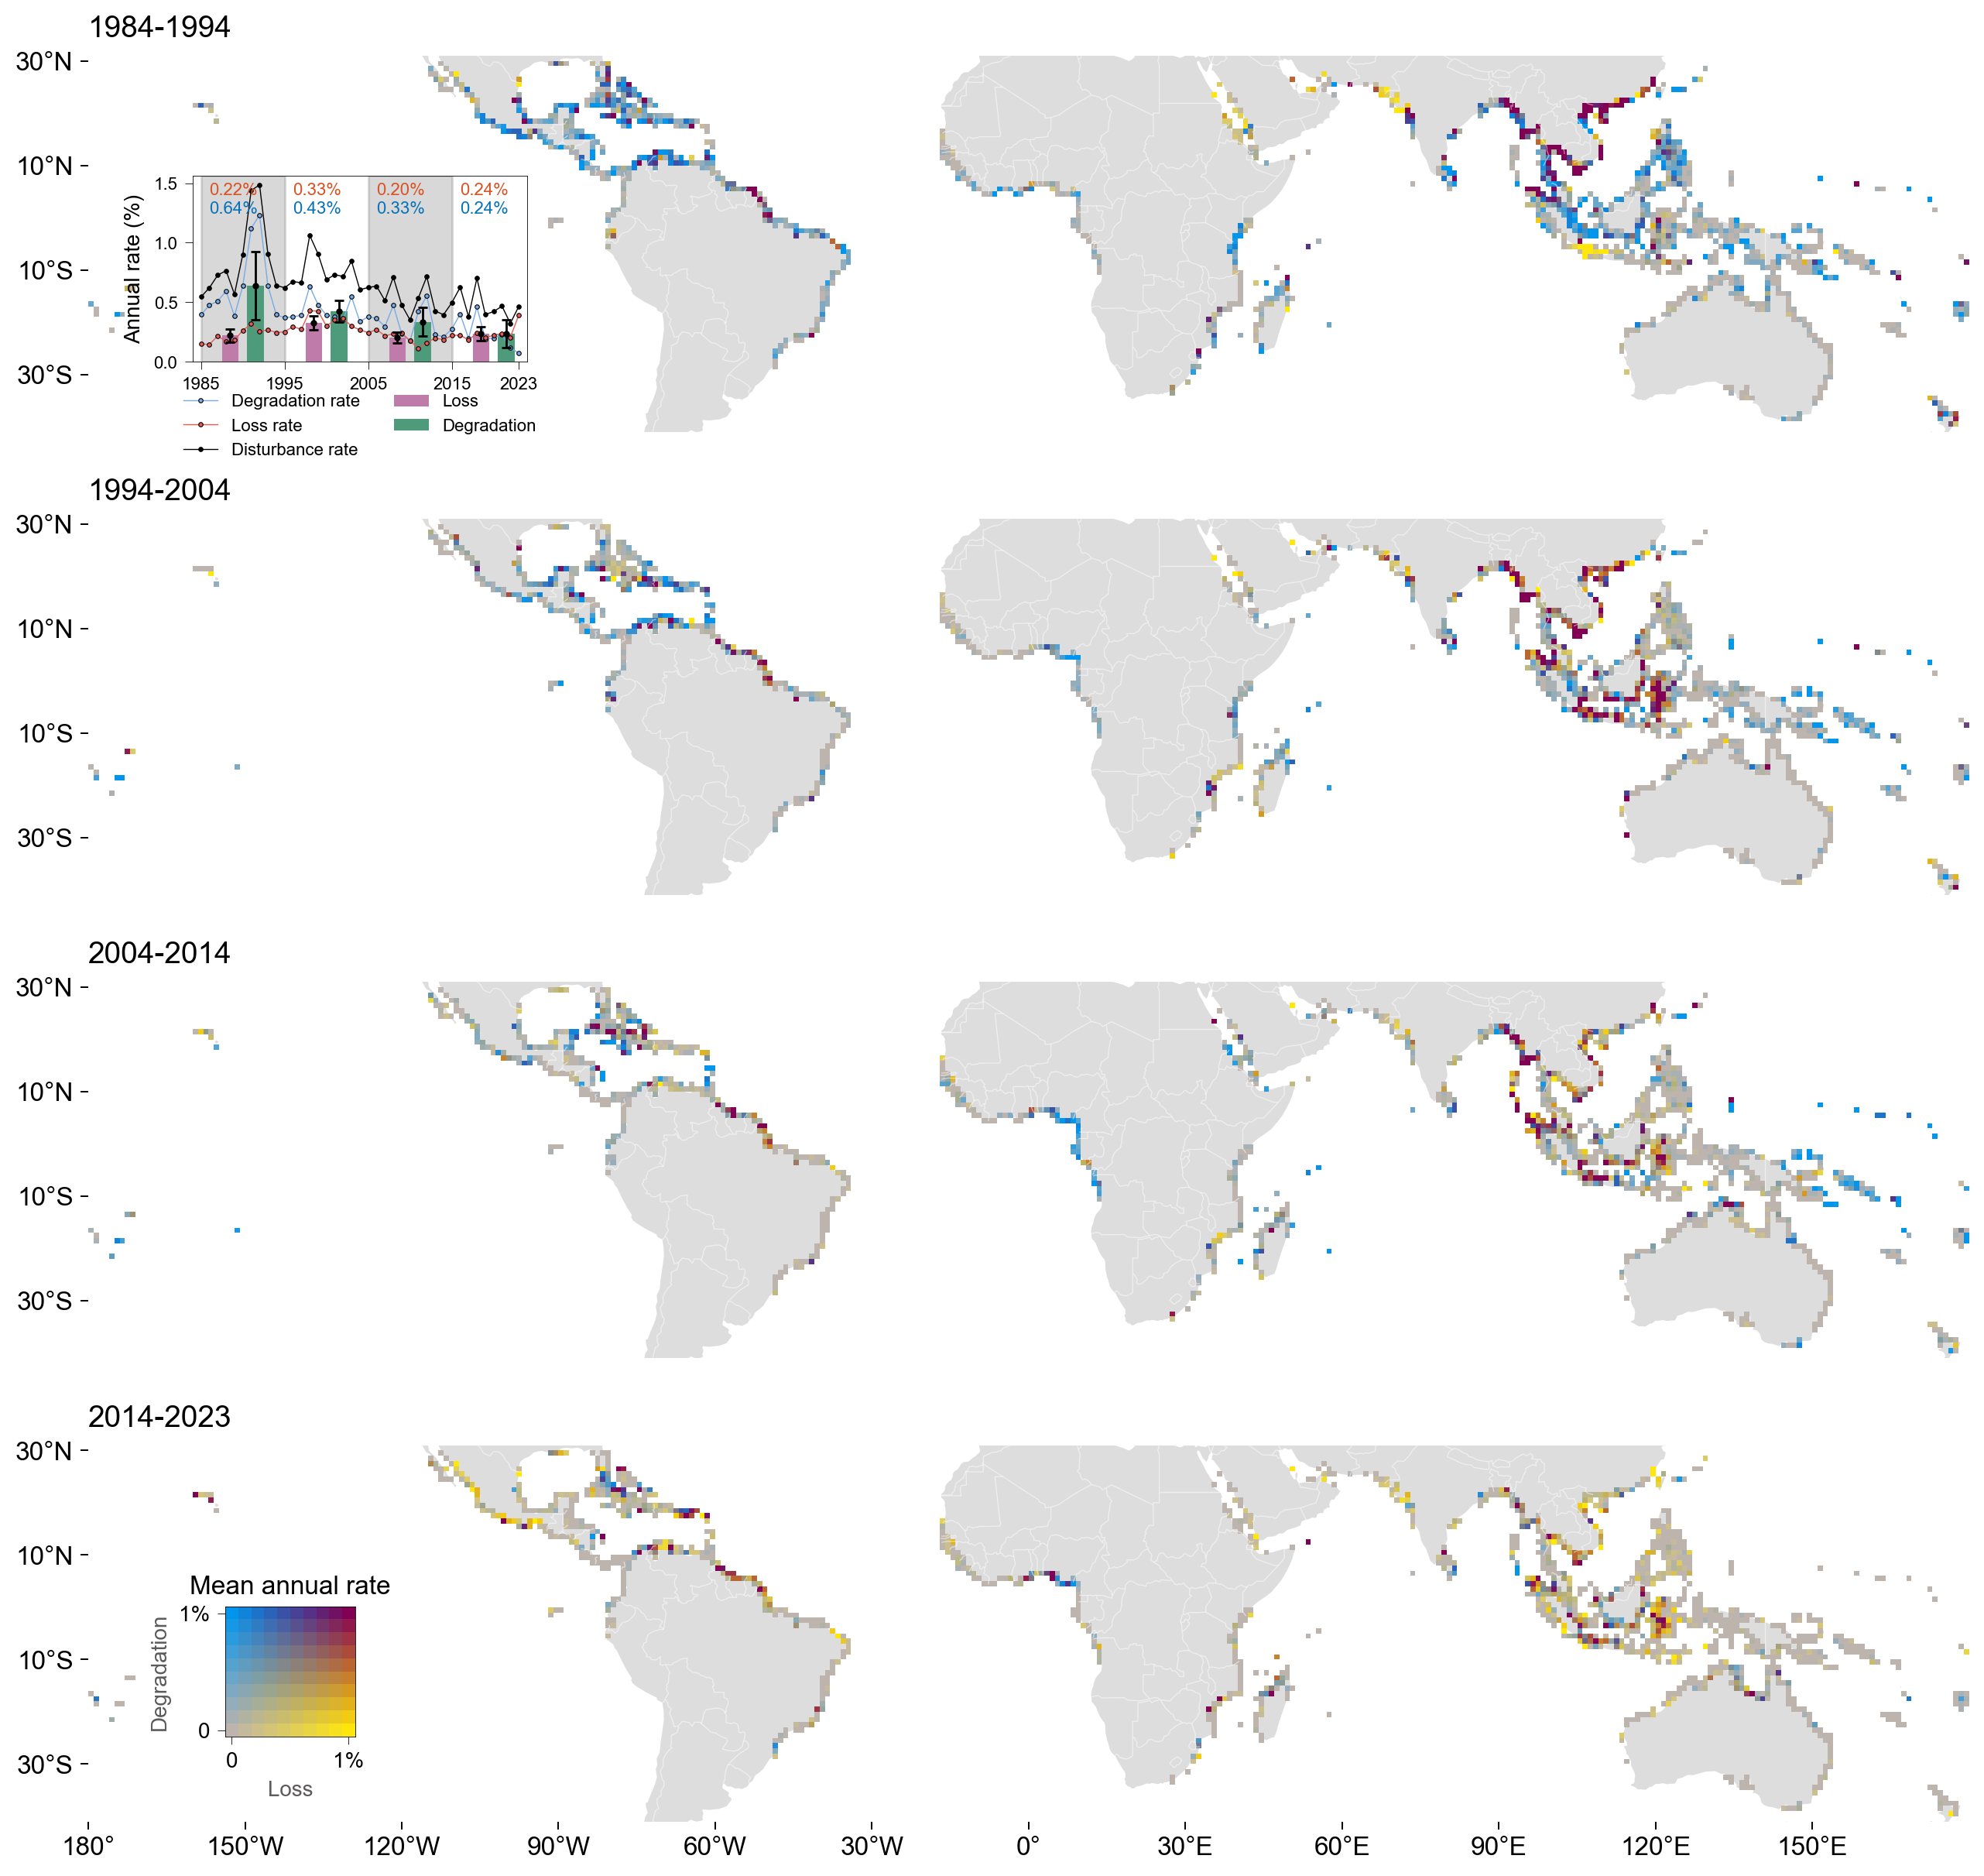

In [ ]:
import importlib
import matplotlib.transforms as transforms
importlib.reload(ZhenPlot)

df_deforestation_annualrate = pd.read_csv('Code_Data/EstimatedAnnualChange/ByGrid_AnnualDeforestationRate_XGBoost.csv')
df_degradation_annualrate = pd.read_csv('Code_Data/EstimatedAnnualChange/ByGrid_AnnualDegradationRate_XGBoost.csv')
gdf_grids = gpd.read_file(r'Code_Data/Grids_1degree.shp') # Read the grid shapefile
gdf_grids = gdf_grids[['ID','geometry']] # Select the columns we need

fig = plt.figure(figsize=(18, 12),constrained_layout=True)
gs = GridSpec(nrows=4, ncols=1,figure=fig,hspace=0.1)
palette = [['#beb4ae','#ffe60b'],['#0195eb','#810053']]

for i,year in enumerate([1984,1994,2004,2014]):
    ax = fig.add_subplot(gs[i,0], projection=ccrs.PlateCarree())
    if i<3: 
        df_deforestation_annualrate['meanlossrate'] = 100*df_deforestation_annualrate[[str(i) for i in range(year,year+10)]].apply(np.mean, axis=1)
        df_degradation_annualrate['meandegrate'] = 100*df_degradation_annualrate[[str(i) for i in range(year,year+10)]].apply(np.mean, axis=1)
        cb = 0; cbpos = []
        secondyear = year+10
        ZhenPlot.add_basemap(ax,xticks=False,yticks=True,fontsize=12)
    else:
        df_deforestation_annualrate['meanlossrate'] = 100*df_deforestation_annualrate[[str(i) for i in range(year,2023)]].apply(np.mean, axis=1)
        df_degradation_annualrate['meandegrate'] = 100*df_degradation_annualrate[[str(i) for i in range(year,2023)]].apply(np.mean, axis=1)
        cb = 1; cbpos = [0.2, 0.07, 0.07, 0.07]  # 位置和大小
        secondyear = 2023
        ZhenPlot.add_basemap(ax,xticks=True,yticks=True,xrange=np.arange(-180,180,30),fontsize=12)

    ax.text(0,1.05,f'{year}-{secondyear}',fontdict={'size' : 14},color='black', transform=ax.transAxes)
    gdf_degradation = gdf_grids.merge(df_degradation_annualrate, left_on='ID', right_on='Region', how='left') # Join the degradation rate with the grid shapefile by the grid ID
    gdf_degradation = gdf_degradation[gdf_degradation['ID'].isin(df_degradation_annualrate['Region'])] # Filter the grids which have degradation data

    gdf_deforestation = gdf_grids.merge(df_deforestation_annualrate, left_on='ID', right_on='Region', how='left') # Join the degradation rate with the grid shapefile by the grid ID
    gdf_deforestation = gdf_deforestation[gdf_deforestation['ID'].isin(df_deforestation_annualrate['Region'])] # Filter the grids which have degradation data
    gdf_both = gdf_deforestation.merge(gdf_degradation[['ID','meandegrate']], left_on='ID', right_on='ID', how='left')
    gdf_both = gdf_both.replace([np.inf, -np.inf]).dropna()
    gdf_both.index = range(len(gdf_both))
        
    if cb == 1:
        cax = fig.add_axes(cbpos)  
        ZhenPlot.BivariatePloting('meanlossrate','meandegrate',gdf_both,ax,palette,cb=cb,cax=cax)
        cax.set_xticklabels(['0', '1%']);cax.set_yticklabels(['0', '1%'])
        cax.set_title('Mean annual rate', fontsize=12)
        cax.set_xlabel('Loss',c="#5d5a5a");cax.set_ylabel('Degradation',c="#5d5a5a")
        ZhenPlot.spine_setting(cax,0.3)
    else:
        ZhenPlot.BivariatePloting('meanlossrate','meandegrate',gdf_both,ax,palette)
    ax.tick_params(axis='both', which='major', width=0.7)
    ax.set_frame_on(False)

    if i == 0:
        ax_inset = fig.add_axes([0.2,0.81,0.12,0.1])
        ax_inset.plot(df_globe['DegradationRate'],label='Degradation rate',c='#77aae7',marker='.',markeredgecolor='k',markersize=4,markeredgewidth=0.4,linewidth=0.5)
        ax_inset.plot(df_globe['DeforestationRate'],label='Loss rate',c='#e85a54',marker='.',markeredgecolor='k',markersize=4,markeredgewidth=0.4,linewidth=0.5)
        ax_inset.plot(df_globe['DeforestationRate']+df_globe['DegradationRate'],label='Disturbance rate',c='k',marker='.',markeredgecolor='k',markersize=4,markeredgewidth=0.4,linewidth=0.5)
        ax_inset.set_xticks([0,10,20,30,38], labels=[1985,1995,2005,2015,2023],fontsize=8)
        plt.yticks(fontsize=8)
        ax_inset.axvspan(0, 10, alpha=0.3, color='gray',zorder=-10);ax_inset.axvspan(20, 30, alpha=0.3, color='grey',zorder=-10)
        ax_inset.set_xlim(-1,39)
        ax_inset.set_ylabel('Annual rate (%)',fontsize=10)
        lossrates,drates = [],[]
        lossrates_std,drates_std = [],[]
        for start in [0,10,20,30]:
            lossrate = np.nanmean(df_globe['DeforestationRate'][start:start+10])
            drate = np.nanmean(df_globe['DegradationRate'][start:start+10])
            lossrate_std = np.nanstd(df_globe['DeforestationRate'][start:start+10])
            drate_std = np.nanstd(df_globe['DegradationRate'][start:start+10])
            trans = transforms.blended_transform_factory(ax_inset.transData, ax_inset.transAxes)
            ax_inset.text(start+1,0.9,f'{lossrate:.2f}%',fontsize=8,color='#d85426', transform=trans)
            ax_inset.text(start+1,0.8,f'{drate:.2f}%',fontsize=8,color='#0873ba', transform=trans)
            lossrates.append(lossrate);drates.append(drate)
            lossrates_std.append(lossrate_std);drates_std.append(drate_std)
        ax_inset.bar([3.5,13.5,23.5,33.5],lossrates,2,color='#bf7cab', label='Loss',edgecolor='none')
        ax_inset.bar([6.5,16.5,26.5,36.5],drates,2,color='#4e9b7b', label='Degradation',edgecolor='none')
        ax_inset.errorbar([3.5,13.5,23.5,33.5],lossrates,lossrates_std,fmt='o', color='black', 
            ecolor='black', elinewidth=1, capsize=2, markersize=2)
        ax_inset.errorbar([6.5,16.5,26.5,36.5],drates,drates_std,fmt='o', color='black', 
            ecolor='black', elinewidth=1, capsize=2, markersize=2)
        plt.legend(loc='lower center',ncol=2, fontsize=8, bbox_to_anchor=(0.5, -0.6), frameon=False)
        ZhenPlot.spine_setting(ax_inset,linewidth=0.3)
        
plt.savefig(r"Figures\MeanLossRateByDecades.png", dpi=500, format='png', bbox_inches='tight')
plt.savefig(r"Figures\MeanLossRateByDecades.svg", dpi=500, format='svg', bbox_inches='tight')